<a href="https://colab.research.google.com/github/KARAN1249/AI-Powered-Brainstorming-Board/blob/main/ML_HEART_PRED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Loading the Dataset

In [3]:
df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Step 3: Data Preprocessing

In [4]:
# Drop unnecessary column
df.drop(columns=['education'], inplace=True)

# Rename column
df.rename(columns={'male': 'Sex_male'}, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (3751, 15)


Step 4: Checking Target Variable

In [5]:
print(df['TenYearCHD'].value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


Step 5: Feature Selection

In [6]:
X = df[['age', 'Sex_male', 'cigsPerDay', 'totChol', 'sysBP', 'glucose']]
y = df['TenYearCHD']

Step 6: Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

Step 7: Training-Testing Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2625, 6)
Test: (1126, 6)


Step 8: Exploratory Data Analysis (EDA)

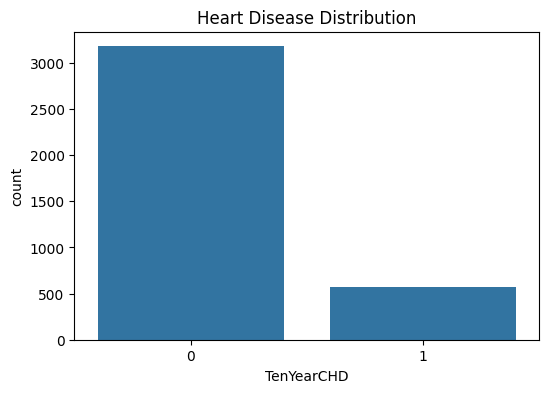

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='TenYearCHD', data=df)
plt.title("Heart Disease Distribution")
plt.show()

Step 9: Import Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

Step 10: Train & Compare Models

In [11]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"{name} Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.8490230905861457
KNN Accuracy: 0.8303730017761989
Decision Tree Accuracy: 0.7522202486678508
Random Forest Accuracy: 0.8410301953818827
SVM Accuracy: 0.8463587921847247


Confusion Matrix


===== Logistic Regression =====
Accuracy: 0.8490230905861457

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92       951
           1       0.61      0.08      0.14       175

    accuracy                           0.85      1126
   macro avg       0.73      0.54      0.53      1126
weighted avg       0.82      0.85      0.80      1126



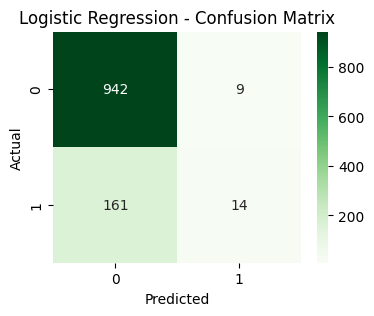


===== KNN =====
Accuracy: 0.8303730017761989

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91       951
           1       0.36      0.11      0.17       175

    accuracy                           0.83      1126
   macro avg       0.61      0.54      0.54      1126
weighted avg       0.78      0.83      0.79      1126



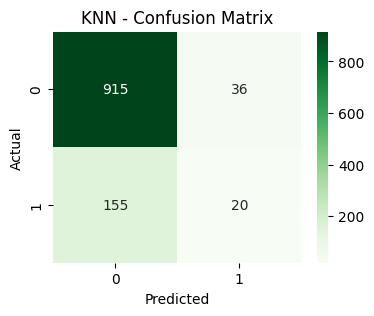


===== Decision Tree =====
Accuracy: 0.7548845470692718

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85       951
           1       0.24      0.27      0.26       175

    accuracy                           0.75      1126
   macro avg       0.55      0.56      0.56      1126
weighted avg       0.77      0.75      0.76      1126



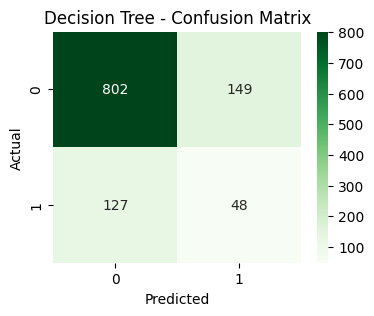


===== Random Forest =====
Accuracy: 0.8383658969804618

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       951
           1       0.41      0.10      0.16       175

    accuracy                           0.84      1126
   macro avg       0.63      0.54      0.53      1126
weighted avg       0.79      0.84      0.79      1126



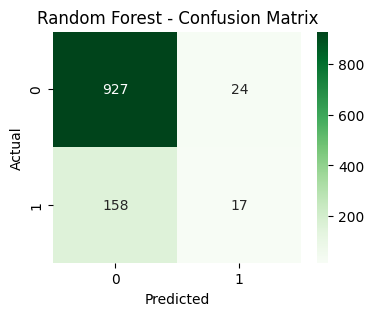


===== SVM =====
Accuracy: 0.8463587921847247

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       951
           1       0.60      0.03      0.06       175

    accuracy                           0.85      1126
   macro avg       0.72      0.52      0.49      1126
weighted avg       0.81      0.85      0.78      1126



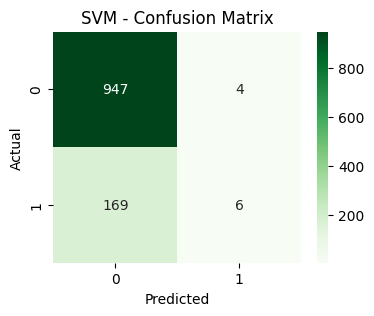

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print("Accuracy:", accuracy)

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Step 11: Visualize Comparison

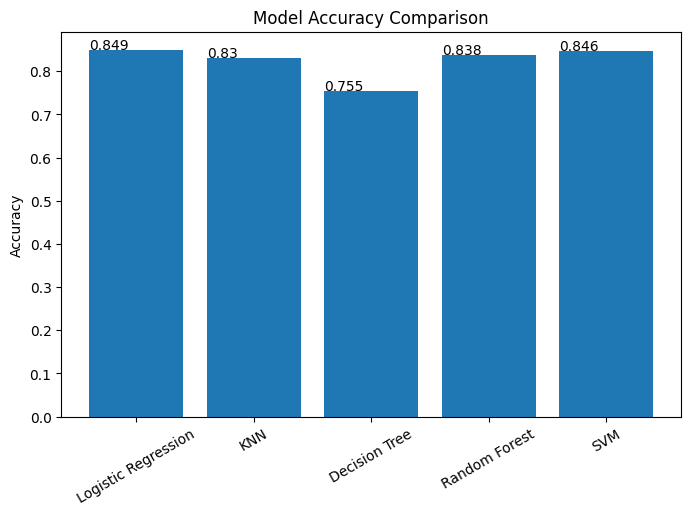

In [13]:
plt.figure(figsize=(8,5))
bars = plt.bar(results.keys(), results.values())

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + 0.001, round(yval, 3))

plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

Step 12: Best Model

In [14]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Logistic Regression


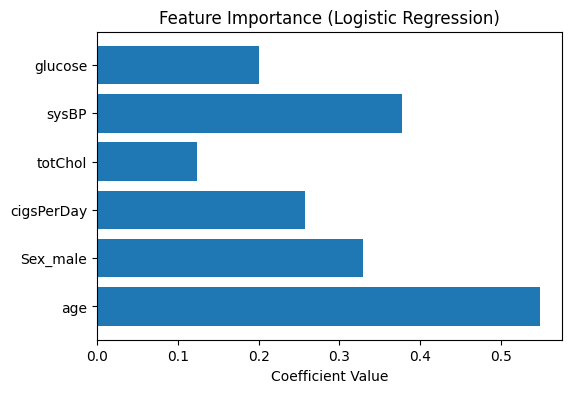

In [15]:
# Get model
model = models["Logistic Regression"]

# Coefficients
importance = model.coef_[0]
features = ['age', 'Sex_male', 'cigsPerDay', 'totChol', 'sysBP', 'glucose']

# Plot
plt.figure(figsize=(6,4))
plt.barh(features, importance)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()